In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [18]:
# Load ground-truth sf data
df_sf = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/sf_tent.csv')

# Drop rows with NaN in 'date' column
df_sf = df_sf.dropna(subset=['date'], axis=0)

# Create timestamp column in df_sf using year, month, and day
df_sf.rename(columns={'date': 'day'}, inplace=True)
df_sf['timestamp'] = pd.to_datetime(df_sf[['year', 'month', 'day']])

df_sf

,year,month,day,tents,structure,sites,tent_struc,timestamp
3,2019,4,23.0,207.0,173.0,442.0,380,2019-04-23
4,2019,4,24.0,207.0,173.0,442.0,380,2019-04-24
5,2019,7,23.0,264.0,187.0,437.0,451,2019-07-23
6,2019,7,24.0,264.0,187.0,437.0,451,2019-07-24
7,2019,10,23.0,272.0,175.0,501.0,447,2019-10-23
8,2020,1,22.0,459.0,190.0,601.0,649,2020-01-22
9,2020,4,20.0,897.0,211.0,427.0,1108,2020-04-20
10,2020,4,21.0,897.0,211.0,427.0,1108,2020-04-21
11,2020,4,22.0,897.0,211.0,427.0,1108,2020-04-22
12,2020,7,29.0,790.0,213.0,426.0,1003,2020-07-29


In [19]:
df_baseline = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/gam_final2_city_daily_predictions_threshold_sweep_stvgpstyle.csv')
df_baseline.head()

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,active_boxes,model,p_thresh
0,2016-01-01,3645.634,3647.5,3517.950,3763.05,3540.95,3753.00,4030,LightGBM-Poisson,0.3
1,2016-01-02,3645.806,3644.0,3533.475,3766.00,3547.95,3747.15,4005,LightGBM-Poisson,0.3
2,2016-01-03,3414.768,3415.5,3313.425,3533.15,3327.95,3512.05,3967,LightGBM-Poisson,0.3
3,2016-01-04,3549.478,3550.0,3430.000,3671.05,3453.00,3653.00,4035,LightGBM-Poisson,0.3
4,2016-01-05,3886.288,3886.0,3771.950,4007.05,3781.00,3992.10,4057,LightGBM-Poisson,0.3


In [20]:
df_baseline['model'].unique()

array(['LightGBM-Poisson', 'NB2_discrete', 'PoissonGLM_L2',
       'SeasonalNaive_lag7', 'ZINB_logit', 'ZIP_logit'], dtype=object)

In [21]:
# Load gamst baseline predictions
df_gamst = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/gam_only3_city_daily_predictions_threshold_sweep_stvgpstyle.csv')
df_gamst.head()

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,active_boxes,model,p_thresh
0,2016-01-01,4545.558,4547.0,4418.950,4671.575,4442.95,4652.10,4379,GAM_ST,0.3
1,2016-01-02,4641.618,4642.0,4503.475,4785.525,4524.00,4757.00,4379,GAM_ST,0.3
2,2016-01-03,4711.500,4709.5,4581.475,4847.000,4599.85,4826.10,4379,GAM_ST,0.3
3,2016-01-04,4734.310,4732.0,4603.375,4868.000,4627.00,4847.10,4379,GAM_ST,0.3
4,2016-01-05,4711.618,4713.0,4579.950,4845.675,4606.90,4828.05,4379,GAM_ST,0.3


In [22]:
# Combine df_baseline and df_gamst
df_baseline = pd.concat([df_baseline, df_gamst], ignore_index=True)
df_baseline['model'].unique()

array(['LightGBM-Poisson', 'NB2_discrete', 'PoissonGLM_L2',
       'SeasonalNaive_lag7', 'ZINB_logit', 'ZIP_logit', 'GAM_ST'],
      dtype=object)

In [23]:
# Convert data in df_baseline to timestamp
df_baseline['timestamp'] = pd.to_datetime(df_baseline['timestamp'])
df_baseline.head()

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,active_boxes,model,p_thresh
0,2016-01-01,3645.634,3647.5,3517.950,3763.05,3540.95,3753.00,4030,LightGBM-Poisson,0.3
1,2016-01-02,3645.806,3644.0,3533.475,3766.00,3547.95,3747.15,4005,LightGBM-Poisson,0.3
2,2016-01-03,3414.768,3415.5,3313.425,3533.15,3327.95,3512.05,3967,LightGBM-Poisson,0.3
3,2016-01-04,3549.478,3550.0,3430.000,3671.05,3453.00,3653.00,4035,LightGBM-Poisson,0.3
4,2016-01-05,3886.288,3886.0,3771.950,4007.05,3781.00,3992.10,4057,LightGBM-Poisson,0.3


In [24]:
# Merge df_baseline and df_sf on 'timestamp'
df_merge_baseline = df_baseline.merge(df_sf[df_sf['timestamp'] < '2025-01-01'][['timestamp', 'tents', 'tent_struc']], on='timestamp', how='left')

# Round p_thresh to 2 decimal places
df_merge_baseline['p_thresh'] = df_merge_baseline['p_thresh'].round(2)

In [25]:
df_merge_baseline['model'].unique()

array(['LightGBM-Poisson', 'NB2_discrete', 'PoissonGLM_L2',
       'SeasonalNaive_lag7', 'ZINB_logit', 'ZIP_logit', 'GAM_ST'],
      dtype=object)

In [26]:
df_merge_baseline.head()

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,active_boxes,model,p_thresh,tents,tent_struc
0,2016-01-01,3645.634,3647.5,3517.950,3763.05,3540.95,3753.00,4030,LightGBM-Poisson,0.3,NaN,NaN
1,2016-01-02,3645.806,3644.0,3533.475,3766.00,3547.95,3747.15,4005,LightGBM-Poisson,0.3,NaN,NaN
2,2016-01-03,3414.768,3415.5,3313.425,3533.15,3327.95,3512.05,3967,LightGBM-Poisson,0.3,NaN,NaN
3,2016-01-04,3549.478,3550.0,3430.000,3671.05,3453.00,3653.00,4035,LightGBM-Poisson,0.3,NaN,NaN
4,2016-01-05,3886.288,3886.0,3771.950,4007.05,3781.00,3992.10,4057,LightGBM-Poisson,0.3,NaN,NaN


In [91]:
# Load Naive and GLM predictions for comparison
df_best = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/gam_final2_city_metrics_threshold_sweep_stvgpstyle.csv')

# Load GAMST
df_best_gamst = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/gam_only3_city_metrics_threshold_sweep_stvgpstyle.csv')

# Combine df_best and df_best_gamst
df_best = pd.concat([df_best, df_best_gamst], ignore_index=True)
df_best.head()

,model,p_thresh,RMSE,MAPE(%),MeanPoissonDev,NLPD
0,LightGBM-Poisson,0.30,3142.406383,587.739325,4107.960538,2058.348375
1,LightGBM-Poisson,0.32,3135.352560,586.293905,4094.520524,2050.996292
2,LightGBM-Poisson,0.34,3126.965763,584.478590,4078.029690,2043.261656
3,LightGBM-Poisson,0.36,3117.009959,582.341540,4057.905007,2032.468850
4,LightGBM-Poisson,0.38,3102.717583,579.025638,4029.790357,2019.468651


In [92]:
# Find the best RMSE and corresponding p_thresh for each model
df_best = df_best.loc[df_best.groupby('model')['RMSE'].idxmin()][['model', 'RMSE', 'MAPE(%)',"MeanPoissonDev","NLPD", 'p_thresh']]
df_best = df_best.reset_index(drop=True)

# Round p_thresh to 2 decimal places
df_best['p_thresh'] = df_best['p_thresh'].round(2)
df_best


,model,RMSE,MAPE(%),MeanPoissonDev,NLPD,p_thresh
0,GAM_ST,620.615803,100.000000,38813.386545,19410.776210,0.74
1,LightGBM-Poisson,419.536790,60.158160,540.634357,274.863345,0.70
2,NB2_discrete,528.926494,82.353452,1455.345630,731.534799,0.70
3,PoissonGLM_L2,496.333023,75.279123,1055.766421,532.156731,0.68
4,SeasonalNaive_lag7,538.009419,84.320613,1368.604147,689.038063,0.38
5,ZINB_logit,546.516595,85.768224,1692.998473,850.115771,0.44
6,ZIP_logit,528.813350,82.348831,1454.313627,731.023941,0.70


In [82]:
df_best_baseline = df_merge_baseline[((df_merge_baseline['model'] == df_best.iloc[0,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[0,2])) |
                                     ((df_merge_baseline['model'] == df_best.iloc[1,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[1,2])) |
                                     ((df_merge_baseline['model'] == df_best.iloc[2,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[2,2])) |
                                     ((df_merge_baseline['model'] == df_best.iloc[3,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[3,2])) |
                                     ((df_merge_baseline['model'] == df_best.iloc[4,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[4,2])) |
                                     ((df_merge_baseline['model'] == df_best.iloc[5,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[5,2])) |
                                     ((df_merge_baseline['model'] == df_best.iloc[6,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[6,2]))]

# df_best_baseline = df_merge_baseline[((df_merge_baseline['model'] == df_best.iloc[0,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[0,2])) |
#                                      ((df_merge_baseline['model'] == df_best.iloc[1,0]) & (df_merge_baseline['p_thresh'] == df_best.iloc[1,2])) |
#                                      ((df_merge_baseline['model'] == df_best.iloc[2,0]) & (df_merge_baseline['p_thresh'] == 0.68)) |
#                                      ((df_merge_baseline['model'] == df_best.iloc[3,0]) & (df_merge_baseline['p_thresh'] == 0.3))]

In [83]:
df_best_baseline['model'].unique()

array(['LightGBM-Poisson', 'NB2_discrete', 'PoissonGLM_L2',
       'SeasonalNaive_lag7', 'ZINB_logit', 'ZIP_logit', 'GAM_ST'],
      dtype=object)

In [84]:
# Remove GAMST, NB2_discrete, ZINB_logit from df_best_baseline for visualization purposes
df_best_baseline = df_best_baseline[df_best_baseline['model'] != 'NB2_discrete']
df_best_baseline['model'].unique()


array(['LightGBM-Poisson', 'PoissonGLM_L2', 'SeasonalNaive_lag7',
       'ZINB_logit', 'ZIP_logit', 'GAM_ST'], dtype=object)

In [85]:
df_best_baseline

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,active_boxes,model,p_thresh,tents,tent_struc
61480,2016-01-01,263.996,264.0,230.475,298.100,237.00,289.00,200,LightGBM-Poisson,0.70,NaN,NaN
61481,2016-01-02,301.264,301.5,268.475,334.525,273.00,330.00,226,LightGBM-Poisson,0.70,NaN,NaN
61482,2016-01-03,202.076,202.0,175.000,229.525,180.00,225.00,148,LightGBM-Poisson,0.70,NaN,NaN
61483,2016-01-04,248.640,249.0,220.475,281.000,226.00,274.00,181,LightGBM-Poisson,0.70,NaN,NaN
61484,2016-01-05,558.464,559.0,509.950,601.525,520.95,595.05,421,LightGBM-Poisson,0.70,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
660905,2024-05-27,6280.428,6280.5,6128.225,6414.575,6167.90,6395.05,4379,GAM_ST,0.74,NaN,NaN
660906,2024-05-28,5265.172,5266.0,5126.375,5396.050,5144.00,5377.15,3799,GAM_ST,0.74,NaN,NaN
660907,2024-05-29,899.708,900.0,840.000,960.525,850.95,950.05,667,GAM_ST,0.74,NaN,NaN
660908,2024-05-30,0.000,0.0,0.000,0.000,0.00,0.00,0,GAM_ST,0.74,NaN,NaN


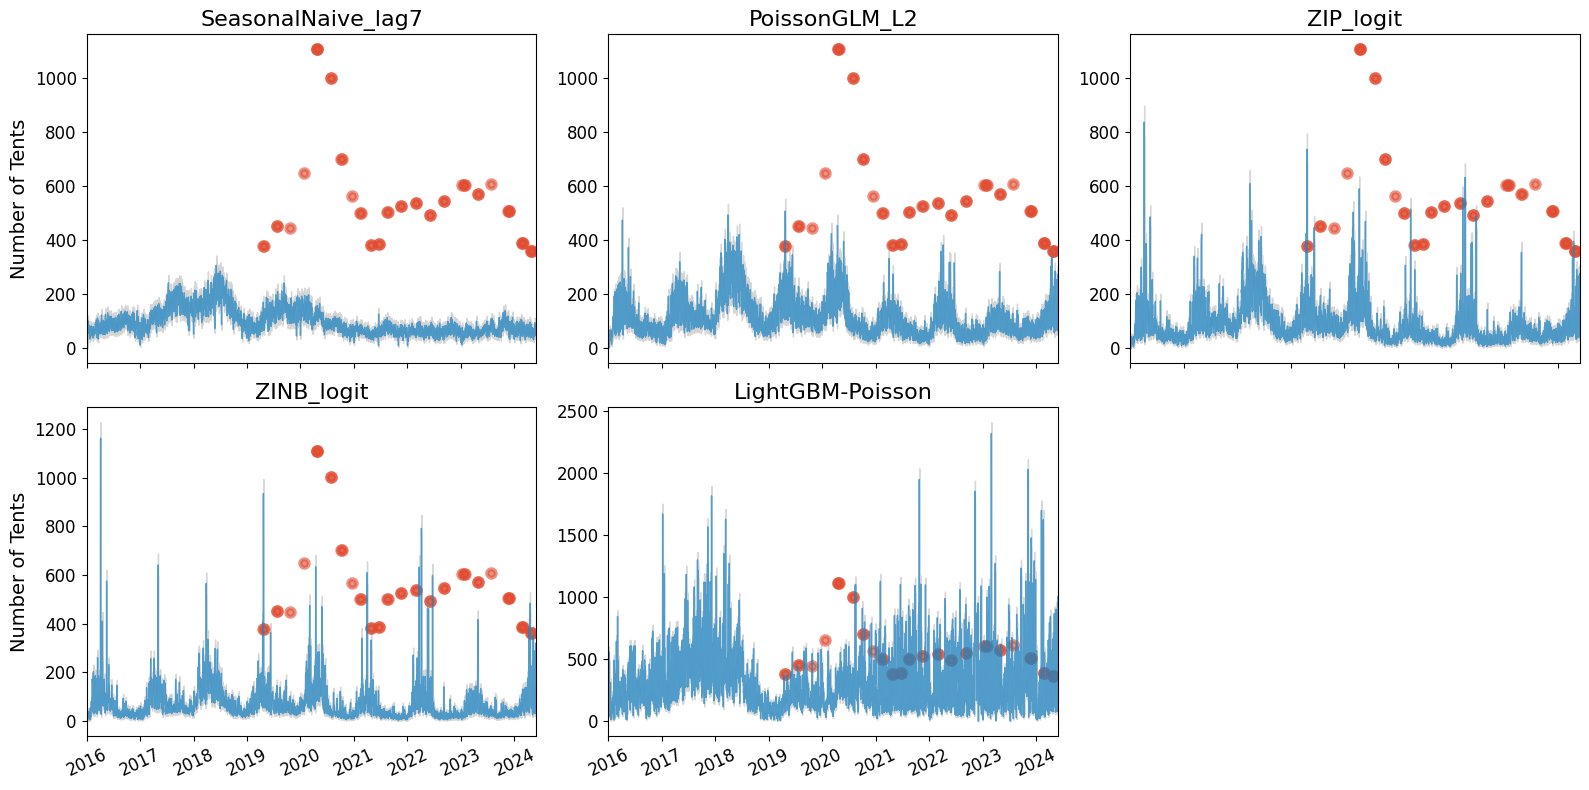

In [89]:
# Create multiple plots for timestamp and mean_total with different models
# Make the figure in the order of 'SeasonalNaive_lag7', 'PoissonGLM_L2', 'NB2_discrete', 'ZIP_logit', 'ZINB_logit', and 'LightGBM-Poisson'
df_best_baseline['model'] = pd.Categorical(df_best_baseline['model'], categories=['SeasonalNaive_lag7', 'PoissonGLM_L2', 'NB2_discrete', 'ZIP_logit', 'ZINB_logit', 'LightGBM-Poisson'], ordered=True)
df_best_baseline = df_best_baseline.sort_values(['model', 'timestamp'])

import datetime as dt
import statsmodels.api as sm

start_date = dt.datetime(2016, 1, 1)
end_date = dt.datetime(2024, 5, 31)
num_plots = df_best_baseline['model'].nunique()
rows = 2
cols = 3

fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 8))
axs = axs.flatten()

for i, model in enumerate(df_best_baseline['model'].unique()):
    # Plot time-series
    axs[i].plot(
        df_best_baseline[df_best_baseline['model']==model]['timestamp'], 
        df_best_baseline[df_best_baseline['model']==model]['mean_total'], 
        #label=model, 
        color='#1984c5',
        alpha=0.7,
        linewidth=1,
    )

    axs[i].scatter(
        df_best_baseline[df_best_baseline['model']==model]['timestamp'], 
        df_best_baseline[df_best_baseline['model']==model]['tent_struc'], 
        label='SF Quarterly Tent Counts', 
        alpha=0.6, 
        marker='o',
        color='#e14b31',
        linewidth=3
    )

    # Uncertainty band
    axs[i].fill_between(
        df_best_baseline[df_best_baseline['model']==model]['timestamp'],
        df_best_baseline[df_best_baseline['model']==model]['lower95'],
        df_best_baseline[df_best_baseline['model']==model]['upper95'],
        color='grey',
        alpha=0.3,
        label='95% Confidence Interval'
    )

    # Remove x-axis tick labels for all but the bottom plots
    if i == 0 or i == 1 or i ==2:
        axs[i].set_xticklabels([])
        
    if i == 3 or i == 4 or i ==5:
        # Rotate x-axis tick labels
        axs[i].tick_params(axis='x', rotation=25)

    if i == 0 or i == 3:
        axs[i].set_ylabel('Number of Tents', fontsize=14)

    # if i == 2:
    #     axs[i].legend(fontsize=12)
    #     axs[i].legend(loc='best', fontsize=12)

    axs[i].set_xlabel('', fontsize=14)
    axs[i].set_xlim(start_date, end_date)
    axs[i].tick_params(axis='both', which='major', labelsize=12)

    # Add title
    axs[i].set_title(model, fontsize=16)

    # Change the legend location
    

axs[5].remove()
plt.tight_layout()
plt.show()

In [176]:
df_merge_baseline

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,active_boxes,model,p_thresh,tents,tent_struc
0,2016-01-01,3645.634,3647.5,3517.950,3763.05,3540.95,3753.00,4030,LightGBM-Poisson,0.30,NaN,NaN
1,2016-01-02,3645.806,3644.0,3533.475,3766.00,3547.95,3747.15,4005,LightGBM-Poisson,0.30,NaN,NaN
2,2016-01-03,3414.768,3415.5,3313.425,3533.15,3327.95,3512.05,3967,LightGBM-Poisson,0.30,NaN,NaN
3,2016-01-04,3549.478,3550.0,3430.000,3671.05,3453.00,3653.00,4035,LightGBM-Poisson,0.30,NaN,NaN
4,2016-01-05,3886.288,3886.0,3771.950,4007.05,3781.00,3992.10,4057,LightGBM-Poisson,0.30,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
590203,2024-05-27,6.490,6.0,2.000,13.00,2.00,11.00,2,ZIP_logit,0.92,NaN,NaN
590204,2024-05-28,6.868,7.0,2.000,12.00,3.00,11.00,2,ZIP_logit,0.92,NaN,NaN
590205,2024-05-29,0.000,0.0,0.000,0.00,0.00,0.00,0,ZIP_logit,0.92,NaN,NaN
590206,2024-05-30,0.000,0.0,0.000,0.00,0.00,0.00,0,ZIP_logit,0.92,NaN,NaN


In [93]:
# Load Naive and GLM predictions for comparison
df_best = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/gam_final2_city_metrics_threshold_sweep_stvgpstyle.csv')
df_best.head()

df_best = df_best[df_best['model'] != 'NB2_discrete']

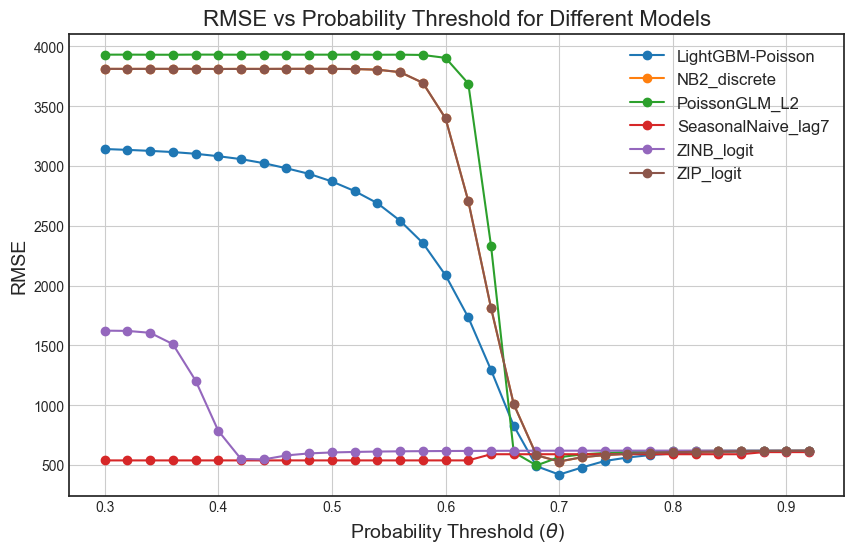

In [183]:
# Create a plot for p_thresh vs RMSE for different models
plt.figure(figsize=(10, 6))
for model in df_best['model'].unique():
    df_model = df_best[df_best['model'] == model]
    plt.plot(df_model['p_thresh'], df_model['RMSE'], marker='o', label=model)

plt.xlabel('Probability Threshold ($\\theta$)', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.title('RMSE vs Probability Threshold for Different Models', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

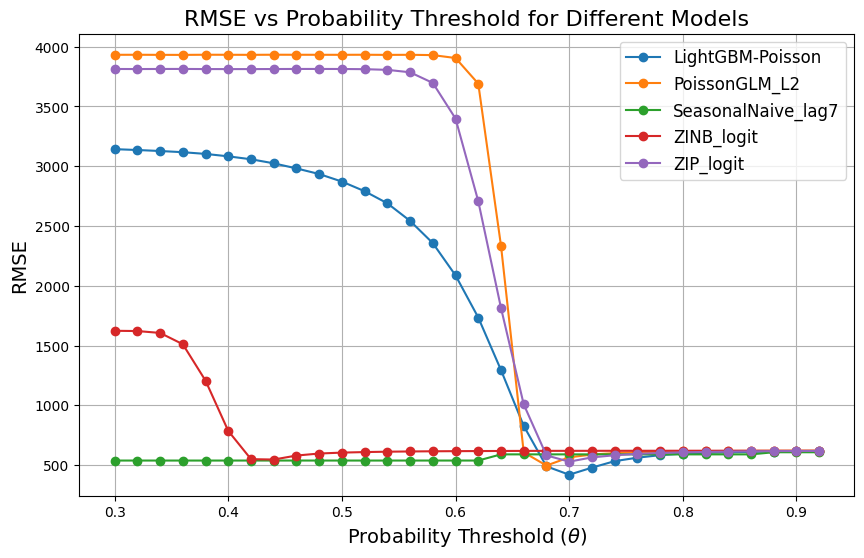

In [94]:
# Create a plot for p_thresh vs RMSE for different models
plt.figure(figsize=(10, 6))
for model in df_best['model'].unique():
    df_model = df_best[df_best['model'] == model]
    plt.plot(df_model['p_thresh'], df_model['RMSE'], marker='o', label=model)

plt.xlabel('Probability Threshold ($\\theta$)', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.title('RMSE vs Probability Threshold for Different Models', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

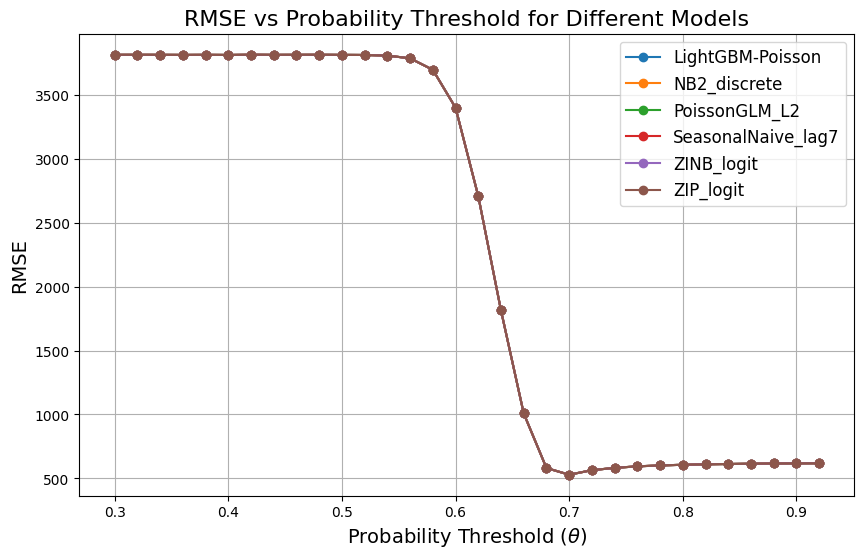

In [76]:
# Create a plot for p_thresh vs RMSE for different models
plt.figure(figsize=(10, 6))
for model in df_best['model'].unique():
    df_model = df_best[df_best['model'] == 'NB2_discrete']
    plt.plot(df_model['p_thresh'], df_model['RMSE'], marker='o', label=model)

plt.xlabel('Probability Threshold ($\\theta$)', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.title('RMSE vs Probability Threshold for Different Models', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [148]:
# Calculate RMSE, MAPE, Poisson Deviance, and NLPD for each model in the baseline dataset
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import poisson
from scipy.special import gammaln

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    poisson_deviance = -2 * (poisson.logpmf(y_true, y_pred).sum())
    nlpd = -poisson.logpmf(y_true, y_pred).mean()

    return rmse, mape, poisson_deviance, nlpd

metrics_results = []
for model in df_best_baseline['model'].unique():
    df_model = df_best_baseline[df_best_baseline['model'] == model]
    y_true = df_model[df_model['tent_struc'].notnull()]['tent_struc']
    y_pred = df_model[df_model['tent_struc'].notnull()]['mean_total']
    rmse, mape, poisson_deviance, nlpd = calculate_metrics(y_true, y_pred)
    metrics_results.append({
        'model': model,
        'RMSE': rmse,
        'MAPE': mape,
        'Poisson Deviance': poisson_deviance,
        'NLPD': nlpd
    })

metrics_df = pd.DataFrame(metrics_results)
metrics_df = metrics_df.sort_values(by='RMSE').reset_index(drop=True)
metrics_df

,model,RMSE,MAPE,Poisson Deviance,NLPD
0,LightGBM-Poisson,394.861129,0.572558,22040.900276,244.898892
1,PoissonGLM_L2,469.406240,0.732565,43002.688078,477.807645
2,SeasonalNaive_lag7,512.621012,0.837818,57410.289213,637.892102
3,GAM_ST,518.586427,0.814633,51971.569166,577.461880


In [102]:
df_merge_baseline['model'].unique()

array(['LightGBM-Poisson', 'PoissonGLM_L2', 'SeasonalNaive_lag7'],
      dtype=object)

In [11]:
df_merge_baseline_eval = df_merge_baseline.dropna(subset=['tent_struc'])
df_merge_baseline_eval.head()

,date,expected_total,sim_mean,sim_q05,sim_q50,sim_q95,active_boxes,model,city_truth,timestamp,tents,tent_struc,p_thresh
1208,2019-04-23,245.150142,246.240,221.95,246.0,270.05,177,LightGBM-Poisson,124.0,2019-04-23,207.0,380.0,NaN
1209,2019-04-24,142.257974,142.668,122.95,143.0,163.00,101,LightGBM-Poisson,147.0,2019-04-24,207.0,380.0,NaN
1299,2019-07-23,161.199296,161.566,141.00,161.0,182.00,108,LightGBM-Poisson,173.0,2019-07-23,264.0,451.0,NaN
1300,2019-07-24,230.160544,231.310,207.95,231.0,256.05,161,LightGBM-Poisson,154.0,2019-07-24,264.0,451.0,NaN
1391,2019-10-23,220.045757,219.784,198.00,219.0,243.00,145,LightGBM-Poisson,173.0,2019-10-23,272.0,447.0,NaN


In [13]:
(5180 - 4380) / 4380 * 100  # Percentage improvement from baseline to ST-VGP

18.2648401826484

In [150]:
# Load our model's predictions for comparison with baseline models
df_stvgp = pd.read_csv('/Users/wooyongjung/Documents/WJ_Projects/HOMELESSSTUDY_EPJDS_2025_v2/data/df_daily_69_noclamp_with_sf_tent.csv')
df_stvgp['timestamp'] = pd.to_datetime(df_stvgp['timestamp'])
df_stvgp.head()

,timestamp,mean_total,median_total,lower95,upper95,lower90,upper90,tents,tent_struc
0,2016-01-01,163.556,163.0,140.475,188.000,143.0,185.0,NaN,NaN
1,2016-01-02,194.666,195.0,168.475,225.000,172.0,220.0,NaN,NaN
2,2016-01-03,222.980,223.0,195.475,252.000,198.0,248.0,NaN,NaN
3,2016-01-04,226.326,225.0,200.000,254.525,203.0,250.0,NaN,NaN
4,2016-01-05,195.222,195.0,167.000,220.525,172.0,217.0,NaN,NaN


In [151]:
# Calculate RMSE, MAPE, Poisson Deviance, and NLPD for df_STVGP
df_stvgp = df_stvgp.dropna(subset=['tent_struc'])
df_stvgp.head()

metrics_results_stvgp = []
y_true = df_stvgp['tent_struc']
y_pred = df_stvgp['mean_total']
rmse, mape, poisson_deviance, nlpd = calculate_metrics(y_true, y_pred)
metrics_results_stvgp.append({
    'model': 'ST-VGP',
    'RMSE': rmse,
    'MAPE': mape,
    'Poisson Deviance': poisson_deviance,
    'NLPD': nlpd
})
metrics_df_stvgp = pd.DataFrame(metrics_results_stvgp)
metrics_df_stvgp = metrics_df_stvgp.sort_values(by='RMSE').reset_index(drop=True)
metrics_df_stvgp

,model,RMSE,MAPE,Poisson Deviance,NLPD
0,ST-VGP,249.519115,0.339027,5940.426283,66.004736


In [15]:
# Calculate RMSE, MAPE, Poisson Deviance, and NLPD for df_STVGP
df_stvgp = df_stvgp.dropna(subset=['tent_struc'])
df_stvgp.head()

metrics_results_stvgp = []
y_true = df_stvgp['tent_struc']
y_pred = df_stvgp['mean_total']
rmse, mape, poisson_deviance, nlpd = calculate_metrics(y_true, y_pred)
metrics_results_stvgp.append({
    'model': 'ST-VGP',
    'RMSE': rmse,
    'MAPE': mape,
    'Poisson Deviance': poisson_deviance,
    'NLPD': nlpd
})
metrics_df_stvgp = pd.DataFrame(metrics_results_stvgp)
metrics_df_stvgp = metrics_df_stvgp.sort_values(by='RMSE').reset_index(drop=True)
metrics_df_stvgp

,model,RMSE,MAPE,Poisson Deviance,NLPD
0,ST-VGP,249.569322,0.338873,5942.182209,66.024247


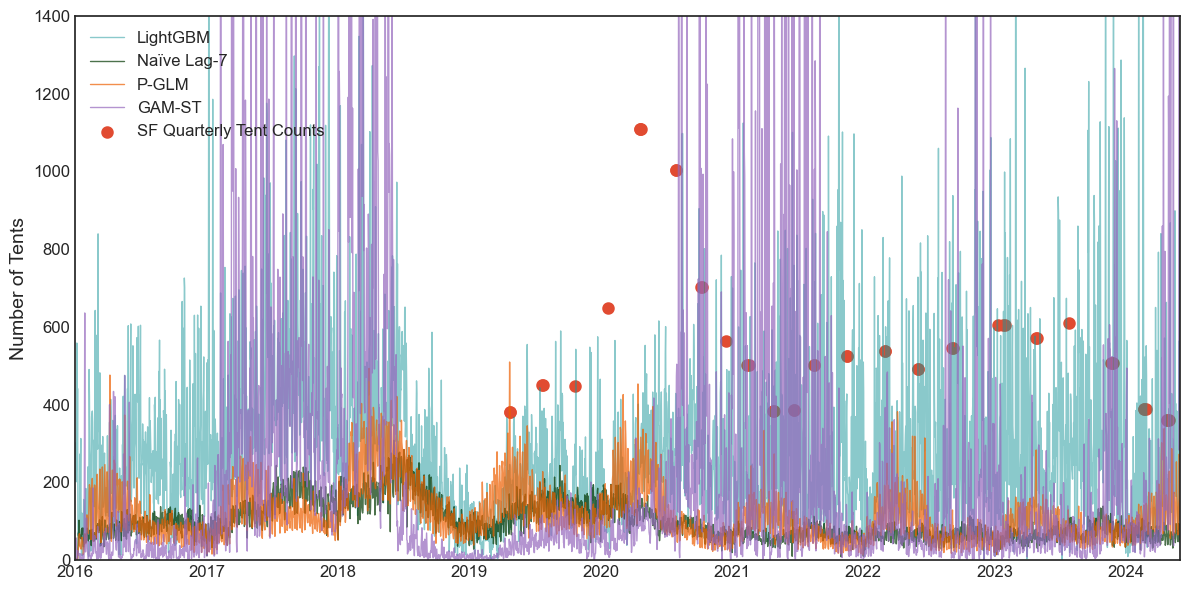

In [153]:
# Compare ST-VGP with Baseline models

start_date = dt.datetime(2016, 1, 1)
end_date = dt.datetime(2024, 5, 31)

# Plot time-series
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-white')

# LightGBM-Poisson
plt.plot(
    df_best_baseline[df_best_baseline['model']=='LightGBM-Poisson']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='LightGBM-Poisson']['mean_total'], 
    label='LightGBM', 
    color='#179599',
    alpha=0.5,
    linewidth=1
)

# Seasonal Naive Lag 7
plt.plot(
    df_best_baseline[df_best_baseline['model']=='SeasonalNaive_lag7']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='SeasonalNaive_lag7']['mean_total'], 
    label='Naïve Lag-7', 
    color='#003600',
    alpha=0.7,
    linewidth=1
)

# PoissonGLM_L2
plt.plot(
    df_best_baseline[df_best_baseline['model']=='PoissonGLM_L2']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='PoissonGLM_L2']['mean_total'], 
    label='P-GLM', 
    color='#ed5f00',
    alpha=0.7,
    linewidth=1
)

# GAM_ST
plt.plot(
    df_best_baseline[df_best_baseline['model']=='GAM_ST']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='GAM_ST']['mean_total'], 
    label='GAM-ST', 
    color='#9467bd',
    alpha=0.7,
    linewidth=1
)


# ST-VGP
# plt.plot(
#     df_stvgp['timestamp'], 
#     df_stvgp['mean_total'], 
#     label='ST-VGP (Our Model)', 
#     color='black',
#     alpha=0.3,
#     linewidth=1
# )

plt.scatter(
    df_stvgp['timestamp'], 
    df_stvgp['tent_struc'], 
    label='SF Quarterly Tent Counts', 
    alpha=1, 
    marker='o',
    color='#e14b31',
    linewidth=3
)

#plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Tents', fontsize=14)
plt.legend(fontsize=12)
plt.xlim(start_date, end_date)
plt.ylim(0,1400)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

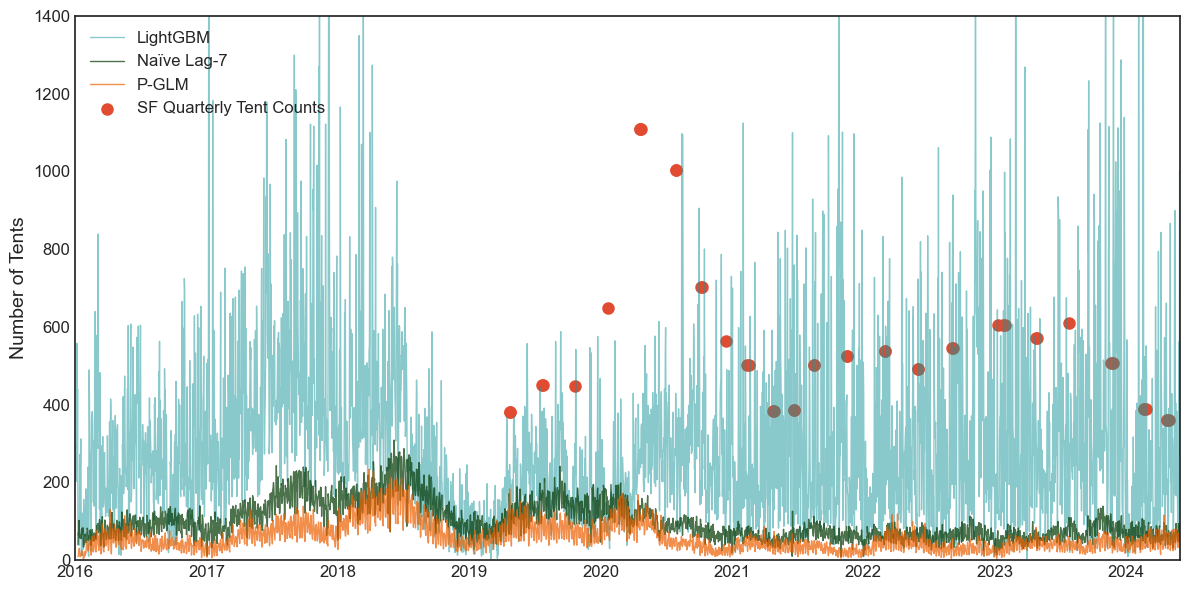

In [ ]:
# Compare ST-VGP with Baseline models

start_date = dt.datetime(2016, 1, 1)
end_date = dt.datetime(2024, 5, 31)

# Plot time-series
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-white')

# LightGBM-Poisson
plt.plot(
    df_best_baseline[df_best_baseline['model']=='LightGBM-Poisson']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='LightGBM-Poisson']['mean_total'], 
    label='LightGBM', 
    color='#179599',
    alpha=0.5,
    linewidth=1
)

# Seasonal Naive Lag 7
plt.plot(
    df_best_baseline[df_best_baseline['model']=='SeasonalNaive_lag7']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='SeasonalNaive_lag7']['mean_total'], 
    label='Naïve Lag-7', 
    color='#003600',
    alpha=0.7,
    linewidth=1
)

# PoissonGLM_L2
plt.plot(
    df_best_baseline[df_best_baseline['model']=='PoissonGLM_L2']['timestamp'], 
    df_best_baseline[df_best_baseline['model']=='PoissonGLM_L2']['mean_total'], 
    label='P-GLM', 
    color='#ed5f00',
    alpha=0.7,
    linewidth=1
)


# ST-VGP
# plt.plot(
#     df_stvgp['timestamp'], 
#     df_stvgp['mean_total'], 
#     label='ST-VGP (Our Model)', 
#     color='black',
#     alpha=0.3,
#     linewidth=1
# )

plt.scatter(
    df_stvgp['timestamp'], 
    df_stvgp['tent_struc'], 
    label='SF Quarterly Tent Counts', 
    alpha=1, 
    marker='o',
    color='#e14b31',
    linewidth=3
)

#plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Tents', fontsize=14)
plt.legend(fontsize=12)
plt.xlim(start_date, end_date)
plt.ylim(0,1400)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()